# Weekend Pre-Lock Strategy - Grid Search Optimization

## 目标
通过二维 Grid Search 找到最优的 `prediction` 和 `confidence` 阈值组合，最大化累计 PnL。

## 交易逻辑
- **Confidence 选择**：
  - `prediction >= 0.5` (看涨) → 使用 `confidence_1`
  - `prediction < 0.5` (看跌) → 使用 `confidence_0`
- **交易规则**：
  - 从周五 22:00 开始监听信号
  - **一旦**出现 `prediction >= threshold_pred` AND `confidence > threshold_conf` → **立即全仓买入**
  - Entry Price = **第一个**符合条件的信号时刻的价格
- **时间窗口**：周五 22:00 - 周六 01:30
- **退出价格**：周六 02:00 ASK price
- **交易规模**：$55M / 周

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from itertools import product
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# 项目路径
PROJECT_ROOT = r'c:\Users\tencentren\CodeBuddy\FX_SYSTEM\bmad-quant-system'
sys.path.insert(0, PROJECT_ROOT)

---
## 1. 数据加载与预处理

In [48]:
# 加载信号数据
signal_file = os.path.join(PROJECT_ROOT, 'data', 'raw', 'USD_SIGNAL_V3.csv')
df = pd.read_csv(signal_file)
df['predict_time'] = pd.to_datetime(df['predict_time'])

print(f"总信号数: {len(df):,}")
print(f"时间范围: {df['predict_time'].min()} 至 {df['predict_time'].max()}")
df.head()

总信号数: 5,497
时间范围: 2025-05-23 21:00:00 至 2026-02-06 00:00:00


,fdate,target_current_pair,predict_time,prediction,confidence_0,confidence_1,is_positive,model_version,fdate_hive_part
0,20250523,USDCNH,2025-05-23 21:00:00,0.472287,0.831944,0.118750,0,v3,p_20250523
1,20250523,USDCNH,2025-05-23 22:00:00,0.559428,0.025000,0.490972,1,v3,p_20250523
2,20250523,USDCNH,2025-05-23 23:00:00,0.616648,0.004167,0.860417,1,v3,p_20250523
3,20250524,USDCNH,2025-05-24 00:00:00,0.638805,0.998611,0.793403,1,v3,p_20250524
4,20250529,USDCNH,2025-05-29 20:00:00,0.477935,0.699306,0.651042,0,v3,p_20250529


In [49]:
# 创建统一的 confidence 列
# prediction >= 0.5 (看涨) -> 使用 confidence_1
# prediction < 0.5 (看跌) -> 使用 confidence_0

df['confidence'] = np.where(
    df['prediction'] >= 0.5,
    df['confidence_1'],  # 上涨预测用 confidence_1
    df['confidence_0']   # 下跌预测用 confidence_0
)

df['direction'] = np.where(df['prediction'] >= 0.5, 'BULLISH', 'BEARISH')

print("Confidence 列创建完成:")
print(f"  - BULLISH (pred >= 0.5): {(df['direction'] == 'BULLISH').sum():,} 条")
print(f"  - BEARISH (pred < 0.5): {(df['direction'] == 'BEARISH').sum():,} 条")

# 显示样本数据
df[['predict_time', 'prediction', 'confidence_0', 'confidence_1', 'confidence', 'direction']].head(10)

Confidence 列创建完成:
  - BULLISH (pred >= 0.5): 3,401 条
  - BEARISH (pred < 0.5): 2,096 条


,predict_time,prediction,confidence_0,confidence_1,confidence,direction
0,2025-05-23 21:00:00,0.472287,0.831944,0.118750,0.831944,BEARISH
1,2025-05-23 22:00:00,0.559428,0.025000,0.490972,0.490972,BULLISH
2,2025-05-23 23:00:00,0.616648,0.004167,0.860417,0.860417,BULLISH
3,2025-05-24 00:00:00,0.638805,0.998611,0.793403,0.793403,BULLISH
4,2025-05-29 20:00:00,0.477935,0.699306,0.651042,0.699306,BEARISH
5,2025-05-29 20:30:00,0.497667,0.195139,0.638542,0.195139,BEARISH
6,2025-05-29 21:00:00,0.605422,0.039931,0.690625,0.690625,BULLISH
7,2025-05-29 21:30:00,0.622661,0.072222,0.907639,0.907639,BULLISH
8,2025-05-29 22:00:00,0.387073,0.733681,0.889931,0.733681,BEARISH
9,2025-05-29 22:30:00,0.468236,0.898264,0.719097,0.898264,BEARISH


---
## 2. 筛选交易窗口信号

In [50]:
# 筛选周五 22:00 - 周六 01:30 的信号
df['hour'] = df['predict_time'].dt.hour
df['minute'] = df['predict_time'].dt.minute
df['time_decimal'] = df['hour'] + df['minute'] / 60
df['weekday'] = df['predict_time'].dt.weekday  # Monday=0, Friday=4, Saturday=5
df['year_week'] = df['predict_time'].dt.strftime('%Y_%W')

# Friday 22:00-23:59
friday_mask = (df['weekday'] == 4) & (df['time_decimal'] >= 22.0)
# Saturday 00:00-01:30
saturday_mask = (df['weekday'] == 5) & (df['time_decimal'] <= 1.5)

trading_signals = df[friday_mask | saturday_mask].copy()
trading_signals = trading_signals.sort_values('predict_time')  # 确保按时间排序

print(f"交易窗口内信号数: {len(trading_signals):,}")
print(f"覆盖周数: {trading_signals['year_week'].nunique()}")

# 每周的信号数量分布
print(f"\n每周平均信号数: {len(trading_signals) / trading_signals['year_week'].nunique():.1f}")

交易窗口内信号数: 172
覆盖周数: 28

每周平均信号数: 6.1


In [51]:
# 查看某一周的信号分布示例
sample_week = trading_signals['year_week'].iloc[0]
sample_signals = trading_signals[trading_signals['year_week'] == sample_week]

print(f"示例周 {sample_week} 的信号 (共 {len(sample_signals)} 条):")
sample_signals[['predict_time', 'prediction', 'confidence', 'direction']].head(20)

示例周 2025_20 的信号 (共 3 条):


,predict_time,prediction,confidence,direction
1,2025-05-23 22:00:00,0.559428,0.490972,BULLISH
2,2025-05-23 23:00:00,0.616648,0.860417,BULLISH
3,2025-05-24 00:00:00,0.638805,0.793403,BULLISH


---
## 3. 获取价格数据 (Bloomberg)

In [52]:
# 导入 Bloomberg 数据获取模块
from backtest.weekend_price_fetcher import WeekendPriceDataFetcher

# 配置
SYMBOL = "USDCNH Curncy"
TRADE_SIZE = 55_000_000  # $55M per week

# 初始化价格获取器
price_fetcher = WeekendPriceDataFetcher()

In [53]:
# 尝试连接 Bloomberg
USE_BLOOMBERG = False  # 设置为 True 以使用真实数据

if USE_BLOOMBERG:
    if price_fetcher.connect():
        print("\n从 Bloomberg 获取真实价格数据...")
        price_df = price_fetcher.get_weekend_prices(
            symbol=SYMBOL,
            start_date=df['predict_time'].min().strftime('%Y-%m-%d'),
            end_date=df['predict_time'].max().strftime('%Y-%m-%d'),
            signal_df=trading_signals
        )
        # 保存数据
        price_fetcher.save_prices(price_df, 'weekend_prices_bbg.csv')
        price_fetcher.disconnect()
    else:
        print("Bloomberg 连接失败，使用模拟数据")
        USE_BLOOMBERG = False

if not USE_BLOOMBERG:
    # 检查是否有已保存的 Bloomberg 数据
    bbg_price_file = os.path.join(PROJECT_ROOT, 'data', 'raw', 'weekend_prices_bbg.csv')
    if os.path.exists(bbg_price_file):
        print("加载已保存的 Bloomberg 价格数据...")
        price_df = pd.read_csv(bbg_price_file)
    else:
        print("使用模拟价格数据...")
        price_df = price_fetcher.generate_mock_prices(
            start_date=df['predict_time'].min().strftime('%Y-%m-%d'),
            end_date=df['predict_time'].max().strftime('%Y-%m-%d')
        )

print(f"\n价格数据: {len(price_df)} 周")
price_df.head(10)

加载已保存的 Bloomberg 价格数据...

价格数据: 37 周


,year_week,friday_date,saturday_date,signal_time,entry_price,exit_price
0,2025_20,2025-05-23,2025-05-24,2025-05-24 00:00:00,NaN,NaN
1,2025_21,2025-05-30,2025-05-31,2025-05-31 00:30:00,NaN,NaN
2,2025_22,2025-06-06,2025-06-07,2025-06-07 00:30:00,NaN,NaN
3,2025_23,2025-06-13,2025-06-14,2025-06-14 00:30:00,NaN,NaN
4,2025_24,2025-06-20,2025-06-21,2025-06-21 00:30:00,NaN,NaN
5,2025_25,2025-06-27,2025-06-28,2025-06-28 00:30:00,NaN,NaN
6,2025_26,2025-07-04,2025-07-05,2025-07-05 00:30:00,NaN,NaN
7,2025_27,2025-07-11,2025-07-12,2025-07-12 00:30:00,NaN,NaN
8,2025_28,2025-07-18,2025-07-19,2025-07-19 00:30:00,NaN,NaN
9,2025_29,2025-07-25,2025-07-26,2025-07-26 00:30:00,7.1692,7.1676


In [54]:
# 创建 Exit Price 字典 (周六 02:00 ASK)
exit_prices = dict(zip(price_df['year_week'], price_df['exit_price']))
print(f"Exit prices (周六 02:00 ASK): {len(exit_prices)} weeks")

# 创建 Entry Price 字典 - 按时间点存储，方便后续查找
# 注意：这里我们需要根据每个信号的时间点获取对应的 Entry Price
# 先创建一个基于 year_week 的 base entry price (信号时刻的价格)
# 实际上，Entry Price 应该是信号发出时的市场价格

# 如果有 Bloomberg，可以获取精确的 tick 价格
# 这里用 Mock 数据，假设同一周的 Entry Price 相同
base_entry_prices = dict(zip(price_df['year_week'], price_df['entry_price']))
print(f"Base entry prices: {len(base_entry_prices)} weeks")

Exit prices (周六 02:00 ASK): 37 weeks
Base entry prices: 37 weeks


---
## 4. 定义回测函数 (使用第一个符合条件的信号)

In [55]:
def run_backtest(pred_threshold, conf_threshold, all_signals, exit_prices, base_entry_prices, trade_size=55_000_000):
    """
    运行单次回测
    
    关键逻辑: 每周从第一个信号开始监听，一旦符合阈值条件就立即全仓买入
    
    Parameters:
    -----------
    pred_threshold : float - Prediction 阈值 (>= pred_threshold)
    conf_threshold : float - Confidence 阈值 (> conf_threshold)
    all_signals : DataFrame - 所有交易窗口内的信号 (已按时间排序)
    
    Returns:
    --------
    dict: 回测结果指标
    """
    total_pnl = 0
    num_trades = 0
    wins = 0
    pnl_list = []
    
    # 按周分组处理
    for week, week_signals in all_signals.groupby('year_week'):
        if week not in exit_prices or pd.isna(exit_prices.get(week)):
            pnl_list.append(0)
            continue
        
        # 在这一周的信号中，找到第一个符合条件的信号
        week_signals = week_signals.sort_values('predict_time')  # 确保按时间排序
        
        first_match = None
        for _, signal in week_signals.iterrows():
            # 检查是否符合阈值条件
            if signal['prediction'] >= pred_threshold and signal['confidence'] > conf_threshold:
                first_match = signal
                break  # 找到第一个符合条件的就停止
        
        if first_match is None:
            # 这周没有符合条件的信号，不交易
            pnl_list.append(0)
            continue
        
        # 有符合条件的信号，执行交易
        # Entry Price = 第一个符合条件的信号时刻的价格
        # 这里使用 base_entry_prices 作为近似 (实际应该用信号时刻的 tick 价格)
        entry = base_entry_prices.get(week)
        exit_p = exit_prices[week]
        
        if pd.isna(entry) or pd.isna(exit_p):
            pnl_list.append(0)
            continue
        
        # 计算 PnL
        pnl = (exit_p - entry) / entry * trade_size
        total_pnl += pnl
        num_trades += 1
        if pnl > 0:
            wins += 1
        pnl_list.append(pnl)
    
    # 计算指标
    pnl_arr = np.array(pnl_list)
    sharpe = (pnl_arr.mean() / pnl_arr.std() * np.sqrt(52)) if pnl_arr.std() > 0 else 0
    win_rate = wins / num_trades if num_trades > 0 else 0
    
    # 最大回撤
    cumsum = np.cumsum(pnl_arr)
    running_max = np.maximum.accumulate(cumsum)
    drawdown = cumsum - running_max
    max_drawdown = drawdown.min()
    
    return {
        'total_pnl': total_pnl,
        'num_trades': num_trades,
        'sharpe_ratio': sharpe,
        'win_rate': win_rate,
        'avg_pnl': total_pnl / num_trades if num_trades > 0 else 0,
        'max_drawdown': max_drawdown
    }

In [56]:
def run_backtest_detailed(pred_threshold, conf_threshold, all_signals, exit_prices, base_entry_prices, trade_size=55_000_000):
    """
    详细回测，返回每笔交易的明细
    """
    trade_details = []
    cumulative_pnl = 0
    
    # 按周分组处理
    for week, week_signals in all_signals.groupby('year_week'):
        if week not in exit_prices or pd.isna(exit_prices.get(week)):
            continue
        
        # 在这一周的信号中，找到第一个符合条件的信号
        week_signals = week_signals.sort_values('predict_time')
        
        first_match = None
        for _, signal in week_signals.iterrows():
            if signal['prediction'] >= pred_threshold and signal['confidence'] > conf_threshold:
                first_match = signal
                break
        
        if first_match is None:
            continue
        
        entry = base_entry_prices.get(week)
        exit_p = exit_prices[week]
        
        if pd.isna(entry) or pd.isna(exit_p):
            continue
        
        pnl = (exit_p - entry) / entry * trade_size
        cumulative_pnl += pnl
        
        trade_details.append({
            'Week': week,
            'Signal_Time': first_match['predict_time'],
            'Prediction': first_match['prediction'],
            'Confidence': first_match['confidence'],
            'Direction': first_match['direction'],
            'Entry_Price': entry,
            'Exit_Price': exit_p,
            'PnL': pnl,
            'Cumulative_PnL': cumulative_pnl
        })
    
    return pd.DataFrame(trade_details)

---
## 5. 验证逻辑：查看某一周的信号触发

In [57]:
# 验证：使用一个阈值组合，查看某周的信号触发情况
test_pred = 0.65
test_conf = 0.40

print(f"测试阈值: prediction >= {test_pred}, confidence > {test_conf}")
print("\n" + "="*80)

# 选取一个有信号的周
for week, week_signals in trading_signals.groupby('year_week'):
    week_signals = week_signals.sort_values('predict_time')
    
    # 找符合条件的信号
    matching_signals = week_signals[
        (week_signals['prediction'] >= test_pred) & 
        (week_signals['confidence'] > test_conf)
    ]
    
    if len(matching_signals) > 0:
        print(f"\n周 {week}:")
        print(f"  总信号数: {len(week_signals)}")
        print(f"  符合条件的信号数: {len(matching_signals)}")
        print(f"  第一个符合条件的信号:")
        first = matching_signals.iloc[0]
        print(f"    时间: {first['predict_time']}")
        print(f"    Prediction: {first['prediction']:.4f}")
        print(f"    Confidence: {first['confidence']:.4f}")
        print(f"    方向: {first['direction']}")
        break

测试阈值: prediction >= 0.65, confidence > 0.4


周 2025_21:
  总信号数: 6
  符合条件的信号数: 2
  第一个符合条件的信号:
    时间: 2025-05-30 23:00:00
    Prediction: 0.7458
    Confidence: 0.5948
    方向: BULLISH


---
## 6. 二维 Grid Search

In [73]:
# 定义搜索范围 (0.01 粒度)
pred_range = np.arange(0.40, 0.9, 0.01)  # 0.50 到 0.85
conf_range = np.arange(0.00, 1.01, 0.01)  # 0.00 到 1.00

total_combinations = len(pred_range) * len(conf_range)
print(f"Prediction 范围: {pred_range.min():.2f} - {pred_range.max():.2f} (共 {len(pred_range)} 个值)")
print(f"Confidence 范围: {conf_range.min():.2f} - {conf_range.max():.2f} (共 {len(conf_range)} 个值)")
print(f"总组合数: {total_combinations:,}")

Prediction 范围: 0.40 - 0.89 (共 50 个值)
Confidence 范围: 0.00 - 1.00 (共 101 个值)
总组合数: 5,050


In [74]:
# 执行 Grid Search
print("开始 Grid Search...")
print("(使用第一个符合条件的信号作为 Entry 时点)")
print()

results = []

for i, pred_th in enumerate(pred_range):
    for conf_th in conf_range:
        metrics = run_backtest(pred_th, conf_th, trading_signals, exit_prices, base_entry_prices, TRADE_SIZE)
        results.append({
            'prediction_threshold': round(pred_th, 2),
            'confidence_threshold': round(conf_th, 2),
            **metrics
        })
    
    if (i + 1) % 10 == 0:
        print(f"进度: {(i+1)*len(conf_range):,}/{total_combinations:,} ({(i+1)/len(pred_range)*100:.0f}%)")

results_df = pd.DataFrame(results)
print(f"\nGrid Search 完成! 共 {len(results_df):,} 种组合")

开始 Grid Search...
(使用第一个符合条件的信号作为 Entry 时点)

进度: 1,010/5,050 (20%)
进度: 2,020/5,050 (40%)
进度: 3,030/5,050 (60%)
进度: 4,040/5,050 (80%)
进度: 5,050/5,050 (100%)

Grid Search 完成! 共 5,050 种组合


---
## 7. 结果分析

In [75]:
# 按 Total PnL 排序
results_by_pnl = results_df.sort_values('total_pnl', ascending=False)

print("=" * 80)
print("TOP 20 参数组合 (按 Total PnL 排序)")
print("=" * 80)
results_by_pnl.head(20)

TOP 20 参数组合 (按 Total PnL 排序)


,prediction_threshold,confidence_threshold,total_pnl,num_trades,sharpe_ratio,win_rate,avg_pnl,max_drawdown
1666,0.56,0.50,92884.208872,11,3.697020,0.909091,8444.018988,-3473.221114
1668,0.56,0.52,92884.208872,11,3.697020,0.909091,8444.018988,-3473.221114
1667,0.56,0.51,92884.208872,11,3.697020,0.909091,8444.018988,-3473.221114
1657,0.56,0.41,91694.666848,13,3.630756,0.846154,7053.435911,-3473.221114
1662,0.56,0.46,90929.598479,12,3.593787,0.833333,7577.466540,-3473.221114
1664,0.56,0.48,90929.598479,12,3.593787,0.833333,7577.466540,-3473.221114
1663,0.56,0.47,90929.598479,12,3.593787,0.833333,7577.466540,-3473.221114
1660,0.56,0.44,90929.598479,12,3.593787,0.833333,7577.466540,-3473.221114
1665,0.56,0.49,90929.598479,12,3.593787,0.833333,7577.466540,-3473.221114
1659,0.56,0.43,90929.598479,12,3.593787,0.833333,7577.466540,-3473.221114


In [61]:
# 最优参数
best = results_by_pnl.iloc[0]

print("\n" + "=" * 60)
print("最优参数 (最大化 PnL)")
print("=" * 60)
print(f"  Prediction Threshold: >= {best['prediction_threshold']:.2f}")
print(f"  Confidence Threshold: > {best['confidence_threshold']:.2f}")
print(f"  ---")
print(f"  Total PnL: ${best['total_pnl']:,.2f}")
print(f"  Sharpe Ratio: {best['sharpe_ratio']:.2f}")
print(f"  Win Rate: {best['win_rate']*100:.1f}%")
print(f"  Number of Trades: {best['num_trades']:.0f}")
print(f"  Avg PnL per Trade: ${best['avg_pnl']:,.2f}")
print(f"  Max Drawdown: ${best['max_drawdown']:,.2f}")


最优参数 (最大化 PnL)
  Prediction Threshold: >= 0.56
  Confidence Threshold: > 0.51
  ---
  Total PnL: $92,884.21
  Sharpe Ratio: 3.70
  Win Rate: 90.9%
  Number of Trades: 11
  Avg PnL per Trade: $8,444.02
  Max Drawdown: $-3,473.22


In [62]:
# 有足够交易次数的最优参数 (>= 5 trades)
results_with_trades = results_by_pnl[results_by_pnl['num_trades'] >= 5]

print("\n" + "=" * 80)
print("TOP 10 参数组合 (交易次数 >= 5, 统计更可靠)")
print("=" * 80)
results_with_trades.head(10)


TOP 10 参数组合 (交易次数 >= 5, 统计更可靠)


,prediction_threshold,confidence_threshold,total_pnl,num_trades,sharpe_ratio,win_rate,avg_pnl,max_drawdown
657,0.56,0.51,92884.208872,11,3.697020,0.909091,8444.018988,-3473.221114
658,0.56,0.52,92884.208872,11,3.697020,0.909091,8444.018988,-3473.221114
656,0.56,0.50,92884.208872,11,3.697020,0.909091,8444.018988,-3473.221114
647,0.56,0.41,91694.666848,13,3.630756,0.846154,7053.435911,-3473.221114
650,0.56,0.44,90929.598479,12,3.593787,0.833333,7577.466540,-3473.221114
651,0.56,0.45,90929.598479,12,3.593787,0.833333,7577.466540,-3473.221114
652,0.56,0.46,90929.598479,12,3.593787,0.833333,7577.466540,-3473.221114
649,0.56,0.43,90929.598479,12,3.593787,0.833333,7577.466540,-3473.221114
655,0.56,0.49,90929.598479,12,3.593787,0.833333,7577.466540,-3473.221114
654,0.56,0.48,90929.598479,12,3.593787,0.833333,7577.466540,-3473.221114


---
## 8. 可视化: PnL 热力图

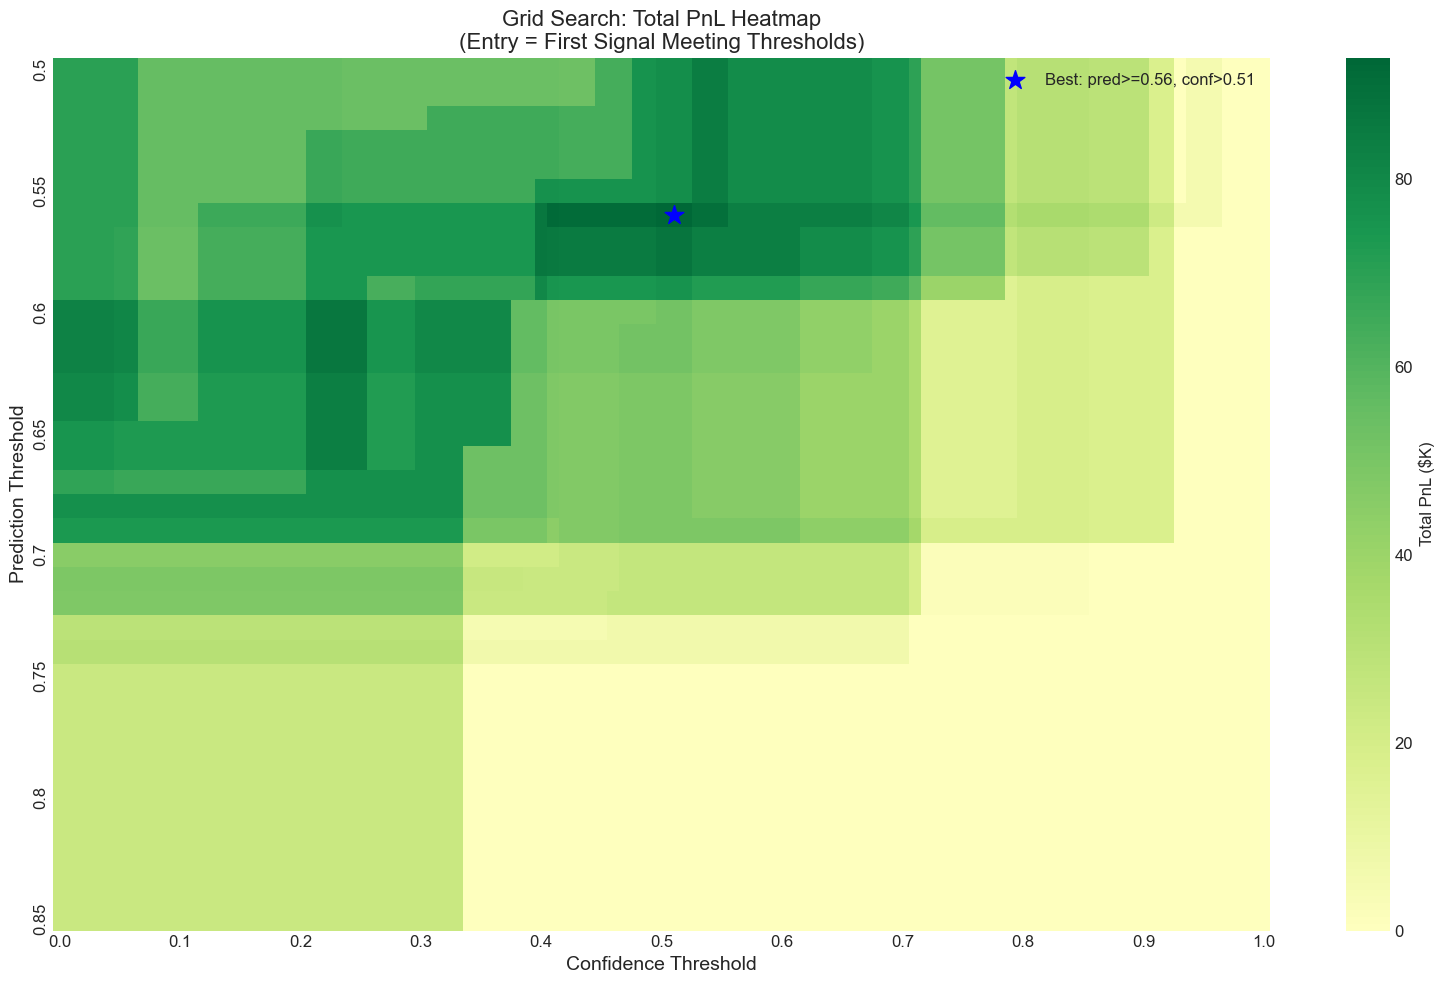

热力图已保存!


In [63]:
# 创建 PnL 热力图数据
pivot_pnl = results_df.pivot_table(
    index='prediction_threshold', 
    columns='confidence_threshold', 
    values='total_pnl'
)

# 绘制热力图
fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    pivot_pnl / 1000,  # 转换为千美元
    cmap='RdYlGn',
    center=0,
    ax=ax,
    cbar_kws={'label': 'Total PnL ($K)'},
    xticklabels=10,  # 每10个显示一个
    yticklabels=5    # 每5个显示一个
)

ax.set_xlabel('Confidence Threshold', fontsize=14)
ax.set_ylabel('Prediction Threshold', fontsize=14)
ax.set_title('Grid Search: Total PnL Heatmap\n(Entry = First Signal Meeting Thresholds)', fontsize=16)

# 标记最优点
best_pred_idx = list(pivot_pnl.index).index(best['prediction_threshold'])
best_conf_idx = list(pivot_pnl.columns).index(best['confidence_threshold'])
ax.scatter([best_conf_idx + 0.5], [best_pred_idx + 0.5], color='blue', s=200, marker='*', label=f'Best: pred>={best["prediction_threshold"]}, conf>{best["confidence_threshold"]}')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'backtest', 'pnl_heatmap.png'), dpi=150)
plt.show()
print("热力图已保存!")

---
## 9. 可视化: Sharpe Ratio 热力图

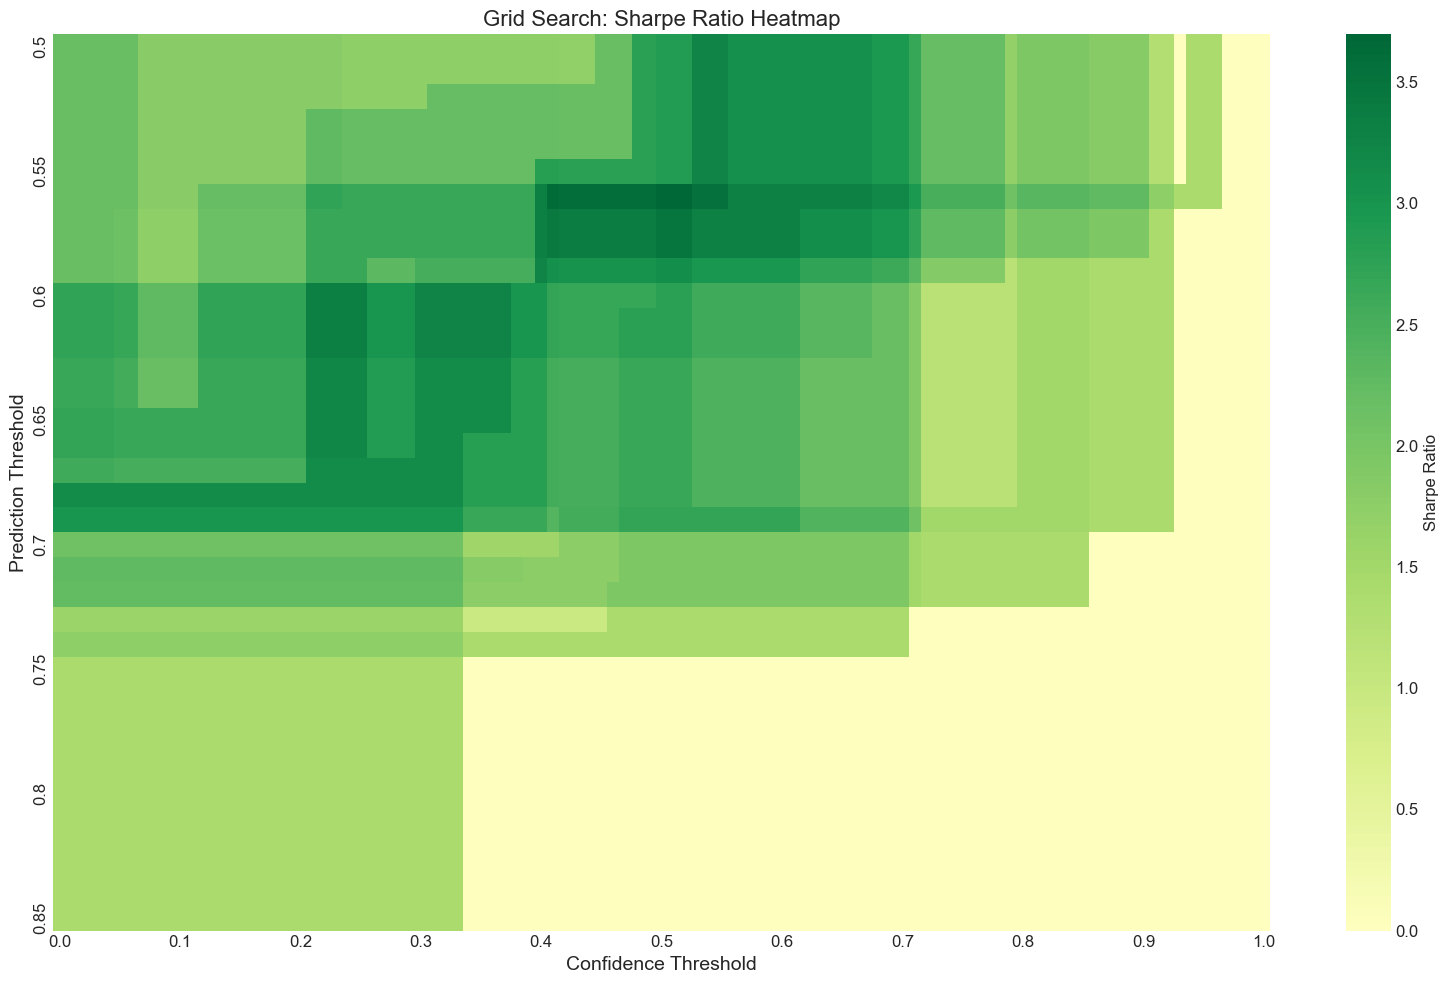

In [64]:
# Sharpe Ratio 热力图
pivot_sharpe = results_df.pivot_table(
    index='prediction_threshold', 
    columns='confidence_threshold', 
    values='sharpe_ratio'
)

fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    pivot_sharpe,
    cmap='RdYlGn',
    center=0,
    ax=ax,
    cbar_kws={'label': 'Sharpe Ratio'},
    xticklabels=10,
    yticklabels=5
)

ax.set_xlabel('Confidence Threshold', fontsize=14)
ax.set_ylabel('Prediction Threshold', fontsize=14)
ax.set_title('Grid Search: Sharpe Ratio Heatmap', fontsize=16)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'backtest', 'sharpe_heatmap.png'), dpi=150)
plt.show()

---
## 10. 可视化: 交易次数热力图

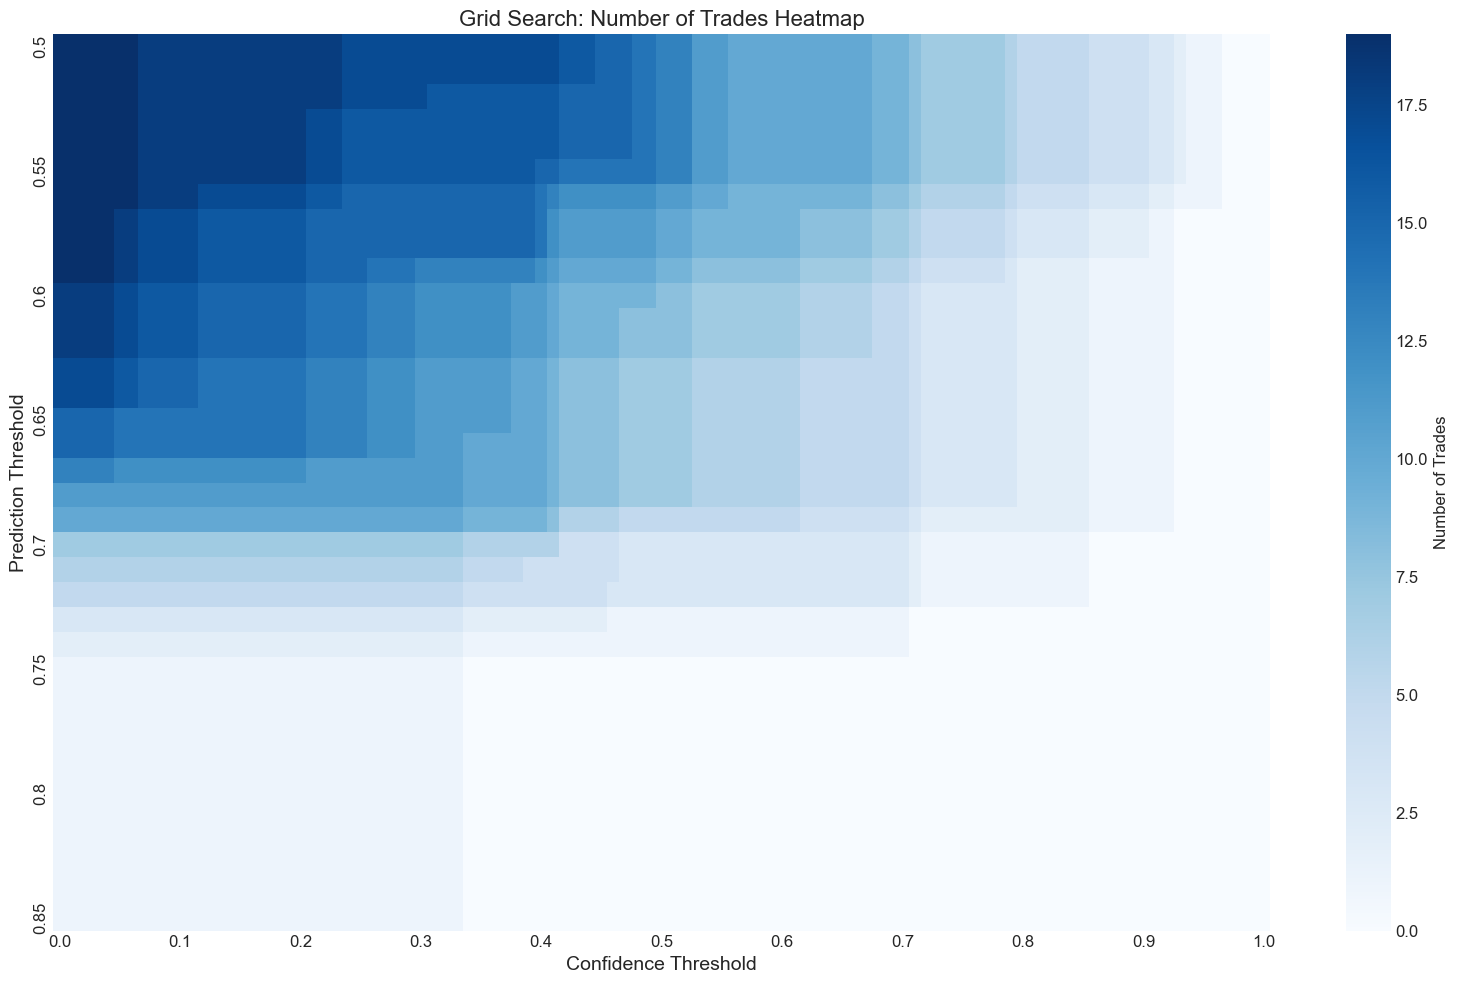

In [65]:
# 交易次数热力图
pivot_trades = results_df.pivot_table(
    index='prediction_threshold', 
    columns='confidence_threshold', 
    values='num_trades'
)

fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    pivot_trades,
    cmap='Blues',
    ax=ax,
    cbar_kws={'label': 'Number of Trades'},
    xticklabels=10,
    yticklabels=5
)

ax.set_xlabel('Confidence Threshold', fontsize=14)
ax.set_ylabel('Prediction Threshold', fontsize=14)
ax.set_title('Grid Search: Number of Trades Heatmap', fontsize=16)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'backtest', 'trades_heatmap.png'), dpi=150)
plt.show()

---
## 11. 最优参数详细回测

In [66]:
# 使用最优参数进行详细回测
best_pred = best['prediction_threshold']
best_conf = best['confidence_threshold']

print(f"使用最优参数: prediction >= {best_pred}, confidence > {best_conf}")
print("\n交易逻辑: 每周从 22:00 开始监听，第一个符合条件的信号立即全仓买入")
print("\n详细交易记录:")

trade_df = run_backtest_detailed(best_pred, best_conf, trading_signals, exit_prices, base_entry_prices, TRADE_SIZE)
trade_df

使用最优参数: prediction >= 0.56, confidence > 0.51

交易逻辑: 每周从 22:00 开始监听，第一个符合条件的信号立即全仓买入

详细交易记录:


,Week,Signal_Time,Prediction,Confidence,Direction,Entry_Price,Exit_Price,PnL,Cumulative_PnL
0,2025_30,2025-08-02 00:30:00,0.599073,0.780952,BULLISH,7.19775,7.2009,24070.021882,24070.021882
1,2025_34,2025-08-30 00:30:00,0.621444,0.677778,BULLISH,7.12195,7.1223,2702.911422,26772.933304
2,2025_39,2025-10-04 00:00:00,0.721508,0.718056,BULLISH,7.13440,7.1367,17730.993496,44503.926800
3,2025_42,2025-10-24 23:00:00,0.561402,0.554514,BULLISH,7.12620,7.1269,5402.598861,49906.525660
4,2025_43,2025-11-01 00:00:00,0.742367,0.705903,BULLISH,7.12380,7.1247,6948.538701,56855.064362
5,2025_44,2025-11-08 00:00:00,0.688989,0.790625,BULLISH,7.12595,7.1255,-3473.221114,53381.843247
6,2025_45,2025-11-15 00:00:00,0.575282,0.732639,BULLISH,7.09760,7.0999,17822.926060,71204.769307
7,2025_48,2025-12-06 00:00:00,0.723753,0.859375,BULLISH,7.06980,7.0700,1555.913887,72760.683194
8,2026_00,2026-01-03 00:00:00,0.688857,0.521181,BULLISH,6.96785,6.9683,3552.028244,76312.711438
9,2026_01,2026-01-09 22:30:00,0.584812,0.903819,BULLISH,6.97625,6.9777,11431.643075,87744.354513


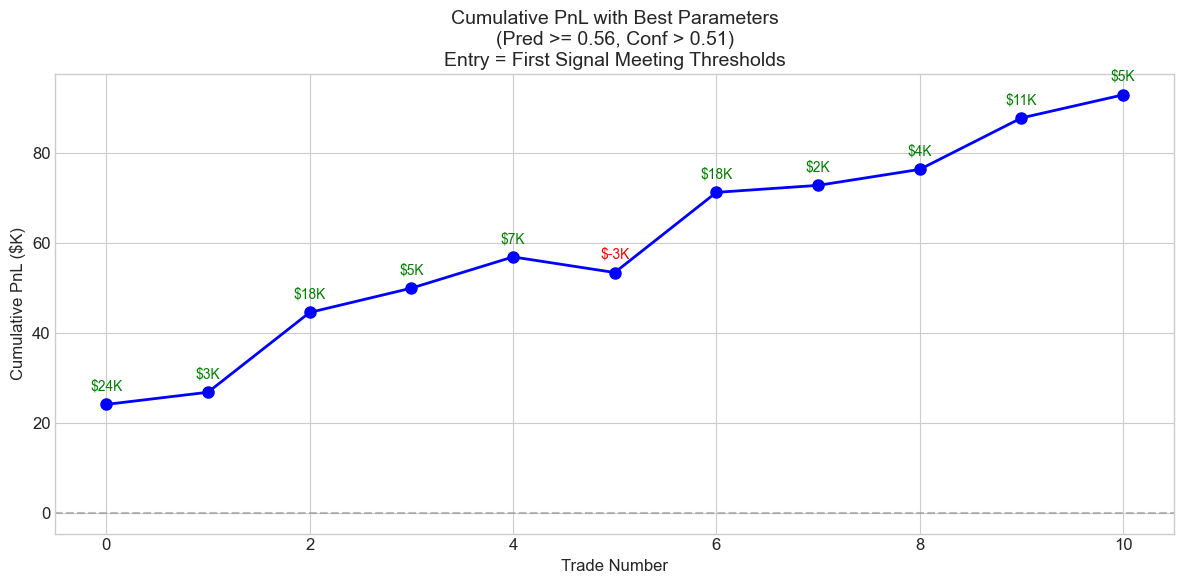

In [67]:
# 累计 PnL 曲线
if len(trade_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(range(len(trade_df)), trade_df['Cumulative_PnL'] / 1000, 'b-o', linewidth=2, markersize=8)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    ax.set_xlabel('Trade Number', fontsize=12)
    ax.set_ylabel('Cumulative PnL ($K)', fontsize=12)
    ax.set_title(f'Cumulative PnL with Best Parameters\n(Pred >= {best_pred}, Conf > {best_conf})\nEntry = First Signal Meeting Thresholds', fontsize=14)
    
    # 标注每个交易的 PnL
    for i, row in trade_df.iterrows():
        color = 'green' if row['PnL'] > 0 else 'red'
        ax.annotate(f"${row['PnL']/1000:.0f}K", 
                    (i, row['Cumulative_PnL']/1000), 
                    textcoords="offset points", 
                    xytext=(0, 10), 
                    ha='center',
                    color=color,
                    fontsize=10)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_ROOT, 'backtest', 'cumulative_pnl.png'), dpi=150)
    plt.show()

In [68]:
# 查看每笔交易的信号时间分布
if len(trade_df) > 0:
    trade_df['Signal_Hour'] = pd.to_datetime(trade_df['Signal_Time']).dt.hour
    trade_df['Signal_Minute'] = pd.to_datetime(trade_df['Signal_Time']).dt.minute
    trade_df['Signal_Time_Str'] = trade_df['Signal_Hour'].astype(str) + ':' + trade_df['Signal_Minute'].astype(str).str.zfill(2)
    
    print("交易信号时间分布:")
    print(trade_df[['Week', 'Signal_Time_Str', 'Prediction', 'Confidence']].to_string())
    
    print(f"\n信号时间统计:")
    print(trade_df.groupby('Signal_Time_Str').size().sort_index())

交易信号时间分布:
       Week Signal_Time_Str  Prediction  Confidence
0   2025_30            0:30    0.599073    0.780952
1   2025_34            0:30    0.621444    0.677778
2   2025_39            0:00    0.721508    0.718056
3   2025_42           23:00    0.561402    0.554514
4   2025_43            0:00    0.742367    0.705903
5   2025_44            0:00    0.688989    0.790625
6   2025_45            0:00    0.575282    0.732639
7   2025_48            0:00    0.723753    0.859375
8   2026_00            0:00    0.688857    0.521181
9   2026_01           22:30    0.584812    0.903819
10  2026_03           23:30    0.562700    0.601389

信号时间统计:
Signal_Time_Str
0:00     6
0:30     2
22:30    1
23:00    1
23:30    1
dtype: int64


---
## 12. 敏感性分析

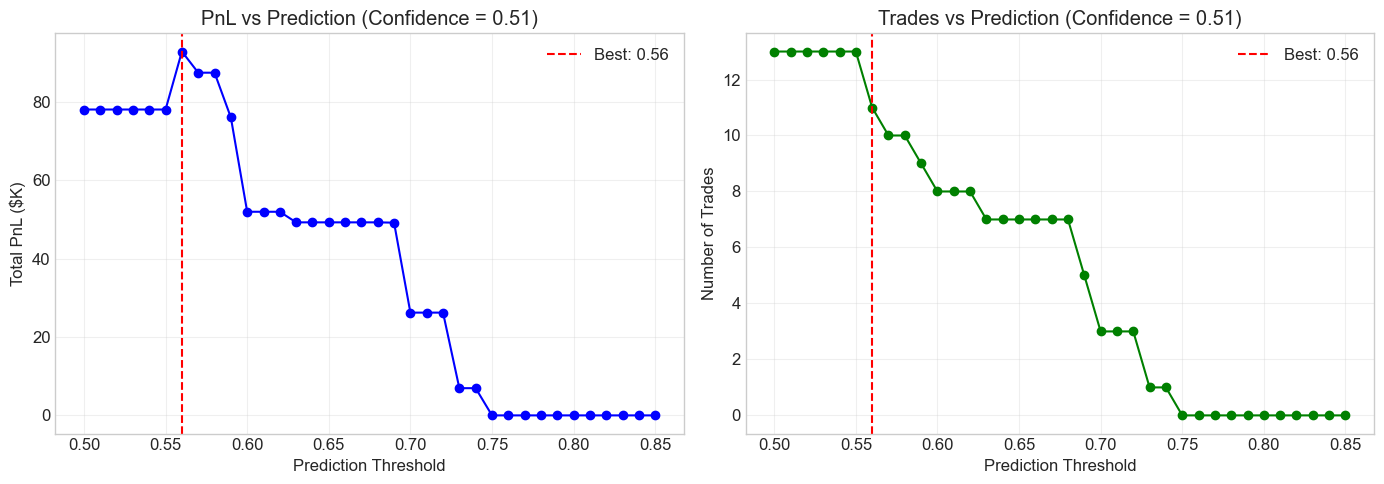

In [69]:
# 固定 confidence，分析 prediction 敏感性
fixed_conf = best_conf
pred_sensitivity = results_df[results_df['confidence_threshold'] == fixed_conf].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PnL vs Prediction
axes[0].plot(pred_sensitivity['prediction_threshold'], pred_sensitivity['total_pnl']/1000, 'b-o')
axes[0].axvline(x=best_pred, color='red', linestyle='--', label=f'Best: {best_pred}')
axes[0].set_xlabel('Prediction Threshold')
axes[0].set_ylabel('Total PnL ($K)')
axes[0].set_title(f'PnL vs Prediction (Confidence = {fixed_conf})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Trades vs Prediction
axes[1].plot(pred_sensitivity['prediction_threshold'], pred_sensitivity['num_trades'], 'g-o')
axes[1].axvline(x=best_pred, color='red', linestyle='--', label=f'Best: {best_pred}')
axes[1].set_xlabel('Prediction Threshold')
axes[1].set_ylabel('Number of Trades')
axes[1].set_title(f'Trades vs Prediction (Confidence = {fixed_conf})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'backtest', 'prediction_sensitivity.png'), dpi=150)
plt.show()

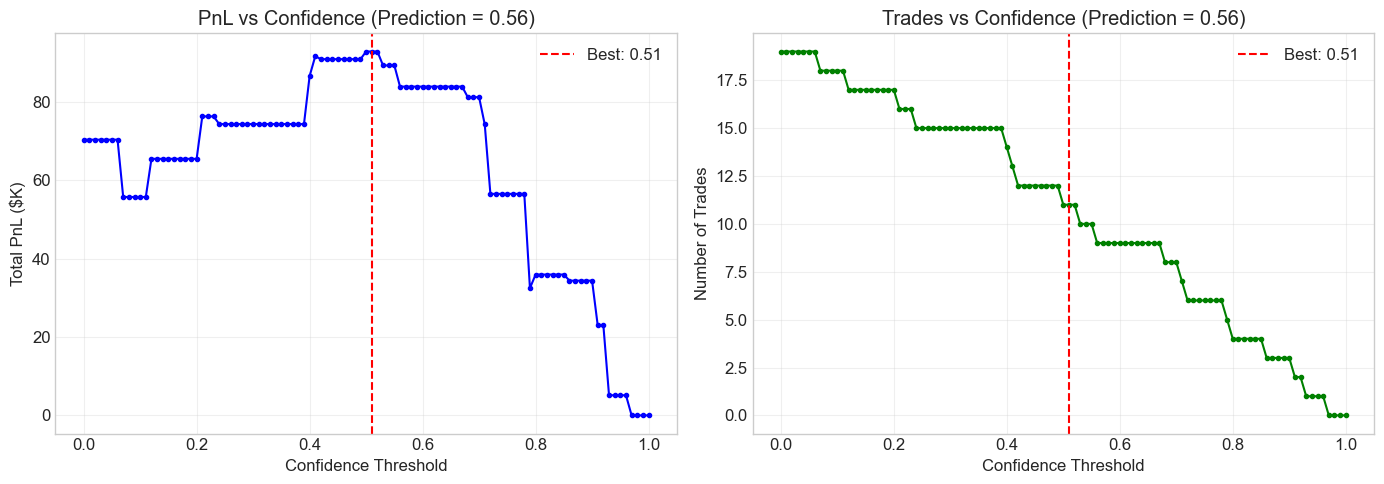

In [70]:
# 固定 prediction，分析 confidence 敏感性
fixed_pred = best_pred
conf_sensitivity = results_df[results_df['prediction_threshold'] == fixed_pred].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PnL vs Confidence
axes[0].plot(conf_sensitivity['confidence_threshold'], conf_sensitivity['total_pnl']/1000, 'b-o', markersize=3)
axes[0].axvline(x=best_conf, color='red', linestyle='--', label=f'Best: {best_conf}')
axes[0].set_xlabel('Confidence Threshold')
axes[0].set_ylabel('Total PnL ($K)')
axes[0].set_title(f'PnL vs Confidence (Prediction = {fixed_pred})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Trades vs Confidence
axes[1].plot(conf_sensitivity['confidence_threshold'], conf_sensitivity['num_trades'], 'g-o', markersize=3)
axes[1].axvline(x=best_conf, color='red', linestyle='--', label=f'Best: {best_conf}')
axes[1].set_xlabel('Confidence Threshold')
axes[1].set_ylabel('Number of Trades')
axes[1].set_title(f'Trades vs Confidence (Prediction = {fixed_pred})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'backtest', 'confidence_sensitivity.png'), dpi=150)
plt.show()

---
## 13. 保存结果

In [71]:
# 保存完整 Grid Search 结果
output_file = os.path.join(PROJECT_ROOT, 'backtest', 'grid_search_full_results.csv')
results_by_pnl.to_csv(output_file, index=False)
print(f"完整结果已保存到: {output_file}")

# 保存交易详情
if len(trade_df) > 0:
    trade_file = os.path.join(PROJECT_ROOT, 'backtest', 'best_params_trades.csv')
    trade_df.to_csv(trade_file, index=False)
    print(f"交易详情已保存到: {trade_file}")

完整结果已保存到: c:\Users\tencentren\CodeBuddy\FX_SYSTEM\bmad-quant-system\backtest\grid_search_full_results.csv
交易详情已保存到: c:\Users\tencentren\CodeBuddy\FX_SYSTEM\bmad-quant-system\backtest\best_params_trades.csv


---
## 14. 总结

In [72]:
print("="*70)
print("GRID SEARCH 总结")
print("="*70)

print(f"\n交易逻辑:")
print(f"  - 从周五 22:00 开始监听信号")
print(f"  - 一旦出现 prediction >= threshold AND confidence > threshold")
print(f"  - 立即全仓买入 $55M USDCNH")
print(f"  - Entry Price = 第一个符合条件的信号时刻的价格")
print(f"  - Exit Price = 周六 02:00 ASK")

print(f"\n搜索空间:")
print(f"  - Prediction: {pred_range.min():.2f} - {pred_range.max():.2f} (步长 0.01)")
print(f"  - Confidence: {conf_range.min():.2f} - {conf_range.max():.2f} (步长 0.01)")
print(f"  - 总组合数: {total_combinations:,}")

print(f"\n最优参数 (最大化 PnL):")
print(f"  - Prediction >= {best['prediction_threshold']:.2f}")
print(f"  - Confidence > {best['confidence_threshold']:.2f}")

print(f"\n最优结果:")
print(f"  - Total PnL: ${best['total_pnl']:,.0f}")
print(f"  - Sharpe Ratio: {best['sharpe_ratio']:.2f}")
print(f"  - Win Rate: {best['win_rate']*100:.1f}%")
print(f"  - Number of Trades: {best['num_trades']:.0f}")
print(f"  - Max Drawdown: ${best['max_drawdown']:,.0f}")

# 稳健推荐
if len(results_with_trades) > 0:
    robust_best = results_with_trades.iloc[0]
    print(f"\n稳健推荐 (>= 5 trades):")
    print(f"  - Prediction >= {robust_best['prediction_threshold']:.2f}")
    print(f"  - Confidence > {robust_best['confidence_threshold']:.2f}")
    print(f"  - Total PnL: ${robust_best['total_pnl']:,.0f}")
    print(f"  - Trades: {robust_best['num_trades']:.0f}")

print("\n" + "="*70)
print("END OF ANALYSIS")
print("="*70)

GRID SEARCH 总结

交易逻辑:
  - 从周五 22:00 开始监听信号
  - 一旦出现 prediction >= threshold AND confidence > threshold
  - 立即全仓买入 $55M USDCNH
  - Entry Price = 第一个符合条件的信号时刻的价格
  - Exit Price = 周六 02:00 ASK

搜索空间:
  - Prediction: 0.50 - 0.85 (步长 0.01)
  - Confidence: 0.00 - 1.00 (步长 0.01)
  - 总组合数: 3,636

最优参数 (最大化 PnL):
  - Prediction >= 0.56
  - Confidence > 0.51

最优结果:
  - Total PnL: $92,884
  - Sharpe Ratio: 3.70
  - Win Rate: 90.9%
  - Number of Trades: 11
  - Max Drawdown: $-3,473

稳健推荐 (>= 5 trades):
  - Prediction >= 0.56
  - Confidence > 0.51
  - Total PnL: $92,884
  - Trades: 11

END OF ANALYSIS
